# SB3 QR-DQN vs FHR-regularised SB3 QR-DQN — CartPole

Stable-Baselines3's best published sample-efficient DQN-family setting for this
env — **RL-Zoo-tuned QR-DQN** (`sb3_contrib`; switch `algo.type: dqn` in the
config for plain SB3 DQN, the zoo tuning is identical apart from `n_quantiles`)
— versus the same method with the **FHR learned-recurrence penalty**
bootstrapped onto its TD loss (`src/agents/sb3_fhr.py`). One config
(`configs/config_sb3.yaml`), one code path (`FHRQRDQN`), one difference per
arm: the **baseline arm** strips the FHR term (`fhr_weight: 0.0`, bit-for-bit
the stock SB3 algorithm — asserted in `tests/test_sb3_fhr.py`); each
**`exp<N>` arm** applies one FHR parameter set from
`experiment.fhr_experiments` on top of the shared `agent:` block. Every arm
trains once per seed in `experiment.seeds`, fanned out as parallel
subprocesses by `../src/run_sb3_seeds.py`, and every comparison figure
reports the seed-average.

The constant `+1`/step reward makes the exact Bellman recurrence roots {1, 1/gamma}, so the low-order AR/ARX penalties target structure that is genuinely present here.

SB3 trains in gradient bursts (`train_freq`/`gradient_steps`), so
`train_diagnostics.csv` holds one row per `train()` burst — the loader below
aggregates rows to per-episode means. The low-rank Hankel sweep, the Q-matrix
rank tracking and the autoregressive value probe are ON by default
(`analysis:` block), dispatched through the same `training.run_analysis_tick`
the classic runs use, so every run records the full mechanism diagnostics —
re-runnable post-hoc on any checkpoint with `../src/run_sb3_analysis.py`.

All artifacts land under `cached/runs/<name>_<timestamp>/` with the manifest
`cached/sb3_runs_manifest.json` and are browsable in the web app:
`python result_viewer_app/rank_viewer.py` → compare mode shows baseline vs
each `exp<N>` as variants of the `sb3_runs` family.

In [1]:
import csv, sys, pathlib, warnings
import matplotlib.pyplot as plt
import numpy as np
import yaml

# NaN-padded seed stacks legitimately have all-NaN columns (episodes before
# training starts / after early-stopped seeds end) — nanmean warns, we don't care.
warnings.filterwarnings("ignore", message="Mean of empty slice")

EXPS = pathlib.Path.cwd().parent / "src"   # stable_baselines_3/src — hosts the shared runner
if str(EXPS) not in sys.path:
    sys.path.insert(0, str(EXPS))

from run_sb3_seeds import launch_all, load_runs, CONFIG

## All arms, all seeds — parallel subprocess fan-out

One training subprocess per (arm, seed): the shared baseline (`fhr_weight: 0.0`
— the single difference, reused from the manifest if already trained) plus one
`exp<N>` arm per entry of the config's `experiment.fhr_experiments`. Completed
runs are recorded in `cached/sb3_runs_manifest.json` — re-running the cell only
launches missing or failed pairs — and each child logs to
`cached/logs/sb3_<arm>_seed<N>.log`.

In [2]:
# Train the shared baseline + every numbered experiment defined in the config.
with open(CONFIG) as f:
    EXP_NUMS = sorted(yaml.safe_load(f)["experiment"].get("fhr_experiments") or {})
print(f"experiments in {CONFIG}: {EXP_NUMS}")
manifest = launch_all(max_workers=6, experiments=EXP_NUMS)
SEEDS = manifest["seeds"]
runs_base = load_runs("baseline")
[r["run_dir"] for r in runs_base]

experiments in configs/config_sb3.yaml: [10, 11, 12]
launching 8 run(s), 6 at a time: [('baseline', 44), ('baseline', 66), ('exp10', 44), ('exp10', 66), ('exp11', 44), ('exp11', 66), ('exp12', 44), ('exp12', 66)]
[baseline seed 66] done in 6.5 min -> cached/runs/sb3_cartpole_baseline_seed66_20260821-134631
[baseline seed 44] done in 6.6 min -> cached/runs/sb3_cartpole_baseline_seed44_20260821-134631
[exp11 seed 44] done in 7.7 min -> cached/runs/sb3_cartpole_exp11_seed44_20260821-134631
[exp10 seed 44] done in 8.0 min -> cached/runs/sb3_cartpole_exp10_seed44_20260821-134631
[exp10 seed 66] done in 8.0 min -> cached/runs/sb3_cartpole_exp10_seed66_20260821-134631
[exp11 seed 66] done in 8.0 min -> cached/runs/sb3_cartpole_exp11_seed66_20260821-134631
[exp12 seed 66] done in 3.8 min -> cached/runs/sb3_cartpole_exp12_seed66_20260821-135308
[exp12 seed 44] done in 4.1 min -> cached/runs/sb3_cartpole_exp12_seed44_20260821-135300


[PosixPath('/home/souparna/Low-Rank-RL-TL/stable_baselines_3/cartpole/cached/runs/sb3_cartpole_baseline_seed44_20260821-134631'),
 PosixPath('/home/souparna/Low-Rank-RL-TL/stable_baselines_3/cartpole/cached/runs/sb3_cartpole_baseline_seed66_20260821-134631')]

## Numbered experiment arms

Loaded from the same manifest. Each arm's FHR parameter set is its
manifest-recorded `agent_overrides` applied on top of the shared `agent:` block
— the `config.yaml` copy inside a run dir does **not** reflect the overrides,
so `agent_by_arm` below is the effective configuration each arm actually
trained with.

In [3]:
ARMS_FHR = [f"exp{n}" for n in EXP_NUMS]
runs_by_arm = {arm: load_runs(arm) for arm in ARMS_FHR}
ALL_ARMS = [("baseline", runs_base)] + [(arm, runs_by_arm[arm]) for arm in ARMS_FHR]

# effective FHR params per arm = shared agent block + the manifest overrides
agent_by_arm = {arm: {**rs[0]["cfg"]["agent"], **(rs[0]["agent_overrides"] or {})}
                for arm, rs in runs_by_arm.items()}
cfg_shared = runs_base[0]["cfg"]   # non-FHR blocks are identical across arms

_PALETTE = ["indianred", "darkorange", "mediumpurple", "seagreen", "goldenrod"]
ARM_COLORS = {"baseline": "steelblue",
              **{arm: _PALETTE[i % len(_PALETTE)] for i, arm in enumerate(ARMS_FHR)}}

def arm_label(arm):
    if arm == "baseline":
        return "baseline (stock SB3, fhr_weight = 0)"
    a = agent_by_arm[arm]
    arx = ", ARX" if a.get("reward_lags") else ""
    return f"{arm} (lambda={a['fhr_weight']}, r={a['fhr_order']}{arx})"

{arm: rs[0]["agent_overrides"] for arm, rs in runs_by_arm.items()}

{'exp10': {'fhr_weight': 0.5,
  'fhr_order': 2,
  'reward_lags': False,
  'c_learning_rate': 0.03},
 'exp11': {'fhr_weight': 1,
  'fhr_order': 2,
  'reward_lags': False,
  'c_learning_rate': 0.015},
 'exp12': {'fhr_weight': 0.1,
  'fhr_order': 2,
  'reward_lags': False,
  'c_learning_rate': 0.015}}

## Comparison figures

All curves below are seed-averages (thin lines, where shown, are single seeds).
Each figure is shown inline and saved as `figures/comparison_<slug>.png` into
**every** run directory (all arms, all seeds), so any run's page in the result
viewer carries the full comparison. Diagnostics rows (one per SB3 `train()`
burst) are aggregated to per-episode means before the seed-average.

In [4]:
def read_diagnostics(run_dir):
    """train_diagnostics.csv -> {column: np.array} aggregated to one value
    per episode (SB3 logs one row per train() burst; several bursts can share
    an episode index, so rows are nanmean-averaged per episode)."""
    path = pathlib.Path(run_dir) / "train_diagnostics.csv"
    with open(path) as f:
        rows = list(csv.DictReader(f))
    eps = sorted({int(float(r["episode"])) for r in rows})
    out = {"episode": np.array(eps, dtype=float)}
    for k in rows[0]:
        if k == "episode":
            continue
        by_ep = {}
        for r in rows:
            by_ep.setdefault(int(float(r["episode"])), []).append(float(r[k]))
        out[k] = np.array([np.nanmean(by_ep[e]) if by_ep[e] else np.nan for e in eps])
    return out

diags_base = [read_diagnostics(r["run_dir"]) for r in runs_base]
diags_by_arm = {arm: [read_diagnostics(r["run_dir"]) for r in rs]
                for arm, rs in runs_by_arm.items()}
ALL_DIAGS = [("baseline", diags_base)] + [(a, diags_by_arm[a]) for a in ARMS_FHR]

ALL_RUN_DIRS = [r["run_dir"] for _, runs in ALL_ARMS for r in runs]

def save_and_show(fig, slug):
    for d in ALL_RUN_DIRS:
        figdir = pathlib.Path(d) / "figures"
        figdir.mkdir(exist_ok=True)
        fig.savefig(figdir / f"comparison_{slug}.png", dpi=150, bbox_inches="tight")
    plt.show()

def rolling(x, w=50):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")

def stack_padded(seqs):
    """(n_seeds, max_len) array, NaN-padded on the right — early-stopped seeds
    are shorter, and the NaN-aware means below only average seeds still running."""
    out = np.full((len(seqs), max(len(s) for s in seqs)), np.nan)
    for i, s in enumerate(seqs):
        out[i, :len(s)] = s
    return out

def diag_seed_mean(diags, key):
    """(episode axis, seed-mean curve) for one diagnostics column, aligned on
    the integer episode index and NaN-padded per seed."""
    n_ep = int(max(d["episode"].max() for d in diags)) + 1
    stack = np.full((len(diags), n_ep), np.nan)
    for i, d in enumerate(diags):
        stack[i, d["episode"].astype(int)] = d[key]
    return np.arange(n_ep), np.nanmean(stack, axis=0)

def episode_steps(r):
    """Per-episode env-step counts: the rewards.csv steps column when the run
    has one, else |reward| — exact here: CartPole pays +1 every step, so |return| is the episode length."""
    if r.get("steps") is not None:
        return np.asarray(r["steps"], dtype=float)
    return np.abs(np.asarray(r["rewards"], dtype=float))

def env_steps_axis(r):
    """Cumulative env steps at the end of each episode — the samples x-axis
    learning curves are reported on in the literature."""
    return np.cumsum(episode_steps(r))

def seed_mean_on_steps(runs, ys, n=400):
    """Seed-average curves whose x values (env steps) don't align across seeds:
    linearly interpolate each seed's (env_steps, y) curve onto a shared grid,
    aggregating only the seeds whose own span covers each grid point — an
    early-stopped seed drops out of the mean instead of being extrapolated.
    ys[i] aligns with the END of runs[i]'s episodes (rolling() output is fine).
    Returns (grid, mean, min, max)."""
    curves = []
    for r, y in zip(runs, ys):
        y = np.asarray(y, dtype=float)
        x = env_steps_axis(r)[-len(y):]
        curves.append((x, y))
    lo = min(float(x[0]) for x, _ in curves)
    hi = max(float(x[-1]) for x, _ in curves)
    grid = np.linspace(lo, hi, n)
    stack = np.full((len(curves), n), np.nan)
    for i, (x, y) in enumerate(curves):
        inside = (grid >= x[0]) & (grid <= x[-1])
        stack[i, inside] = np.interp(grid[inside], x, y)
    return (grid, np.nanmean(stack, axis=0),
            np.nanmin(stack, axis=0), np.nanmax(stack, axis=0))

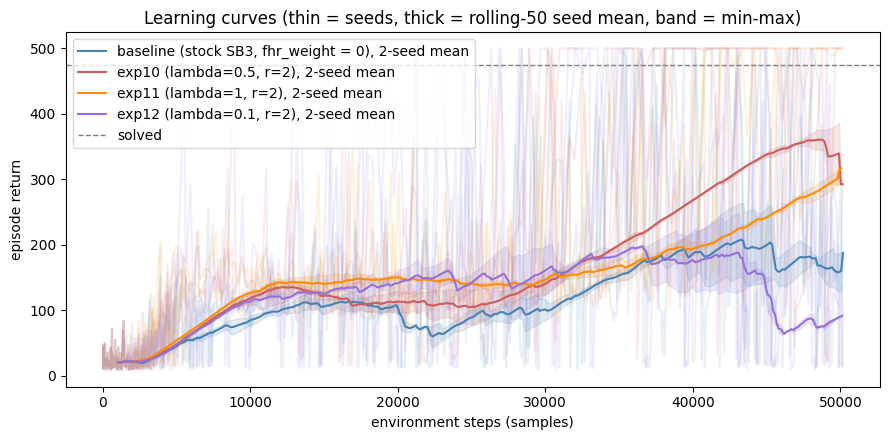

In [5]:
# -- learning curves (x = environment steps, i.e. samples collected) ----------
W = 50
fig, ax = plt.subplots(figsize=(9, 4.5))
for arm, runs in ALL_ARMS:
    for r in runs:
        ax.plot(env_steps_axis(r), r["rewards"], alpha=0.12, color=ARM_COLORS[arm])
for arm, runs in ALL_ARMS:
    grid, m, lo, hi = seed_mean_on_steps(runs, [rolling(r["rewards"], W) for r in runs])
    ax.plot(grid, m, color=ARM_COLORS[arm],
            label=f"{arm_label(arm)}, {len(SEEDS)}-seed mean")
    ax.fill_between(grid, lo, hi, color=ARM_COLORS[arm], alpha=0.15)
ax.axhline(cfg_shared["training"]["solved_reward"], ls="--", c="gray", lw=1, label="solved")
ax.set_xlabel("environment steps (samples)")
ax.set_ylabel("episode return")
ax.set_title(f"Learning curves (thin = seeds, thick = rolling-{W} seed mean, band = min-max)")
ax.legend()
fig.tight_layout()
save_and_show(fig, "learning_curves")

## Reference: the standard RL-Zoo baseline

The tuned recipe (Polyak τ=0.005 + lr 4e-3 — the fresh-target port from
`../mountaincar_tuning/TUNING_LOG.md`) changed the *base config under both
arms*, so the `lambda=0` arm above is the scientifically **paired** baseline.
This section adds the **published** reference: the stock RL-Zoo recipe from
`configs/config_sb3_zoo.yaml` (published zoo QR-DQN: 500.0 ± 0.0,
deterministic eval), launched into its own manifest via
`launch_all(config=..., arms=["baseline"])`. Note CartPole's zoo entry
already syncs hard every 10 steps — an ultra-fresh target — so this env tests
smooth-vs-fresh, not stale-vs-fresh. Cross-recipe curves are compared on
greedy eval (`eval.csv`), not training reward.

launching 2 run(s), 2 at a time: [('baseline', 44), ('baseline', 66)]
[baseline seed 66] done in 2.3 min -> cached/runs/sb3_cartpole_zoo_baseline_seed66_20260821-135708
[baseline seed 44] done in 2.3 min -> cached/runs/sb3_cartpole_zoo_baseline_seed44_20260821-135708


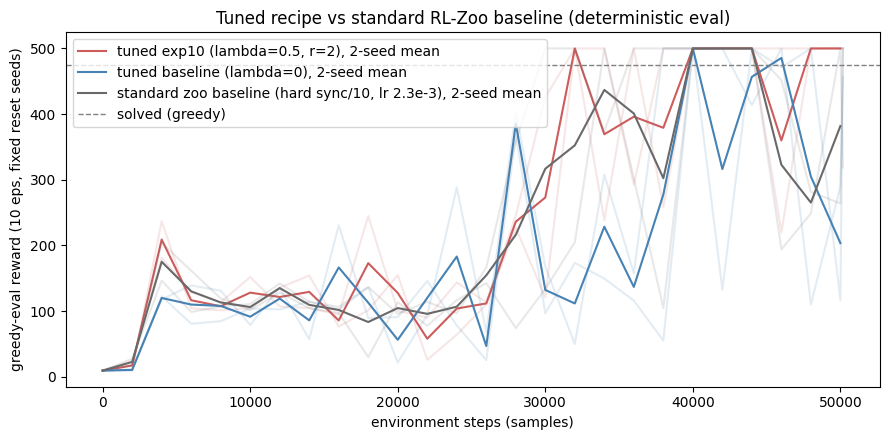

In [6]:
# -- tuned recipe vs the standard RL-Zoo baseline (greedy eval) ---------------
# configs/config_sb3_zoo.yaml = the stock zoo recipe (hard sync/10, lr 2.3e-3),
# run as an external reference. Its runs land in their own manifest
# (cached/sb3_runs_manifest_zoo.json), so they never collide with the tuned
# arms above; re-running the cell only launches missing pairs.
ZOO_CONFIG = "configs/config_sb3_zoo.yaml"
launch_all(max_workers=6, config=ZOO_CONFIG, arms=["baseline"])
runs_zoo = load_runs("baseline", config=ZOO_CONFIG)

def eval_curve(run_dir):
    """eval.csv -> (env_steps, greedy mean reward) — the deterministic-eval
    curve, the only measure comparable across recipes (the published zoo
    500.0 +/- 0.0 is deterministic eval, not a training curve)."""
    t = np.genfromtxt(pathlib.Path(run_dir) / "eval.csv", delimiter=",",
                      names=True, ndmin=1)
    return t["env_steps"], t["mean_reward"]

BEST_FHR = ARMS_FHR[0]          # exp10 = the cross-env headline FHR block
GRID = np.arange(0, 50001, 2000)
fig, ax = plt.subplots(figsize=(9, 4.5))
for label, runs, color in [
        (f"tuned {arm_label(BEST_FHR)}", runs_by_arm[BEST_FHR], ARM_COLORS[BEST_FHR]),
        ("tuned baseline (lambda=0)", runs_base, "steelblue"),
        ("standard zoo baseline (hard sync/10, lr 2.3e-3)", runs_zoo, "dimgray")]:
    curves = [eval_curve(r["run_dir"]) for r in runs]
    for s, v in curves:
        ax.plot(s, v, color=color, alpha=0.15)
    # np.interp holds an early-stopped (solved) seed's last eval value forward
    m = np.mean([np.interp(GRID, s, v) for s, v in curves], axis=0)
    ax.plot(GRID, m, color=color, label=f"{label}, {len(curves)}-seed mean")
ax.axhline(475, ls="--", c="gray", lw=1, label="solved (greedy)")
ax.set_xlabel("environment steps (samples)")
ax.set_ylabel("greedy-eval reward (10 eps, fixed reset seeds)")
ax.set_title("Tuned recipe vs standard RL-Zoo baseline (deterministic eval)")
ax.legend()
fig.tight_layout()
save_and_show(fig, "zoo_reference_eval")

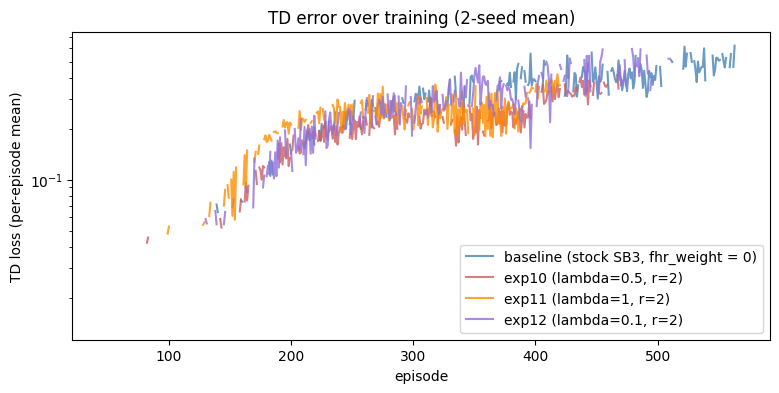

In [7]:
# -- TD error over training --------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
for arm, diags in ALL_DIAGS:
    ax.plot(*diag_seed_mean(diags, "td_loss"), color=ARM_COLORS[arm], alpha=0.8,
            label=arm_label(arm))
ax.set_xlabel("episode"); ax.set_ylabel("TD loss (per-episode mean)")
ax.set_yscale("log")
ax.set_title(f"TD error over training ({len(SEEDS)}-seed mean)")
ax.legend()
save_and_show(fig, "td_error")

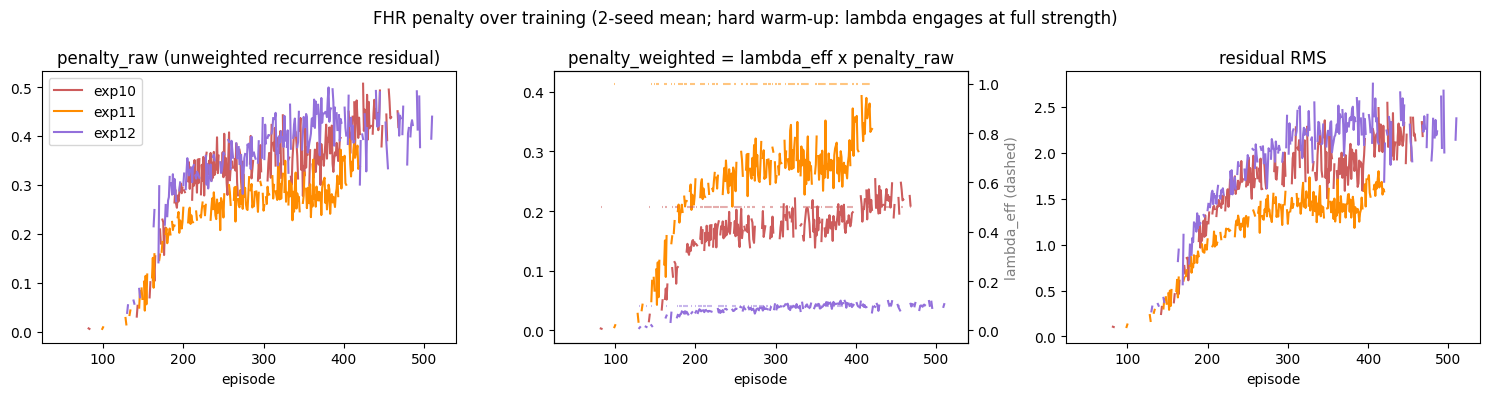

In [8]:
# -- regularisation penalty over training (seed means) -----------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ax2 = axes[1].twinx()
for arm in ARMS_FHR:
    diags, color = diags_by_arm[arm], ARM_COLORS[arm]
    axes[0].plot(*diag_seed_mean(diags, "penalty_raw"), color=color, label=arm)
    axes[1].plot(*diag_seed_mean(diags, "penalty_weighted"), color=color)
    ax2.plot(*diag_seed_mean(diags, "lambda_eff"), color=color, ls="--", alpha=0.5)
    axes[2].plot(*diag_seed_mean(diags, "residual_rms"), color=color)
axes[0].set_title("penalty_raw (unweighted recurrence residual)")
axes[0].legend()
axes[1].set_title("penalty_weighted = lambda_eff x penalty_raw")
ax2.set_ylabel("lambda_eff (dashed)", color="gray")
axes[2].set_title("residual RMS")
for ax in axes:
    ax.set_xlabel("episode")
fig.suptitle(f"FHR penalty over training ({len(SEEDS)}-seed mean; hard warm-up: lambda engages at full strength)")
fig.tight_layout()
save_and_show(fig, "penalty")

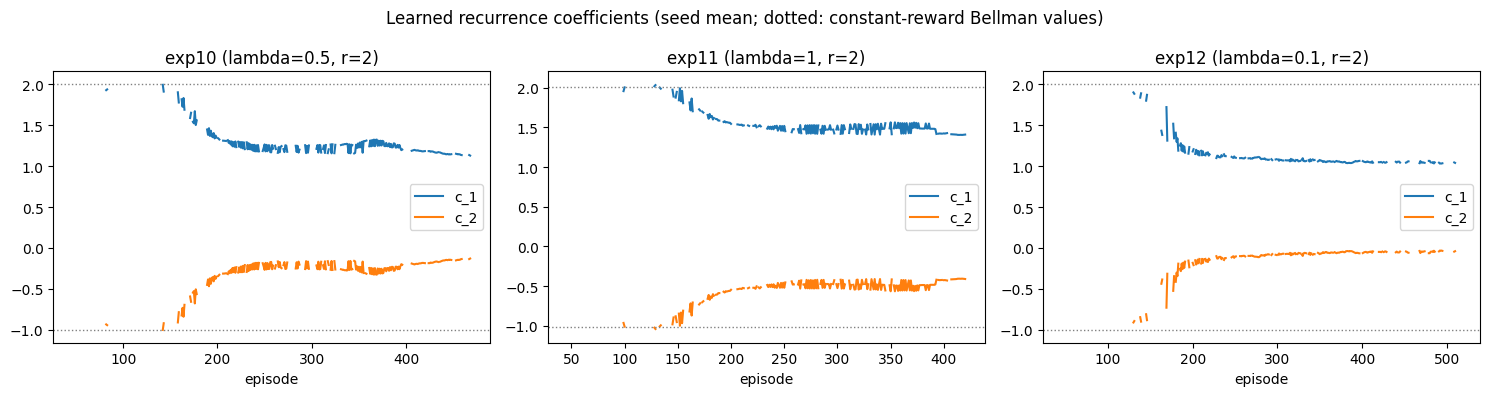

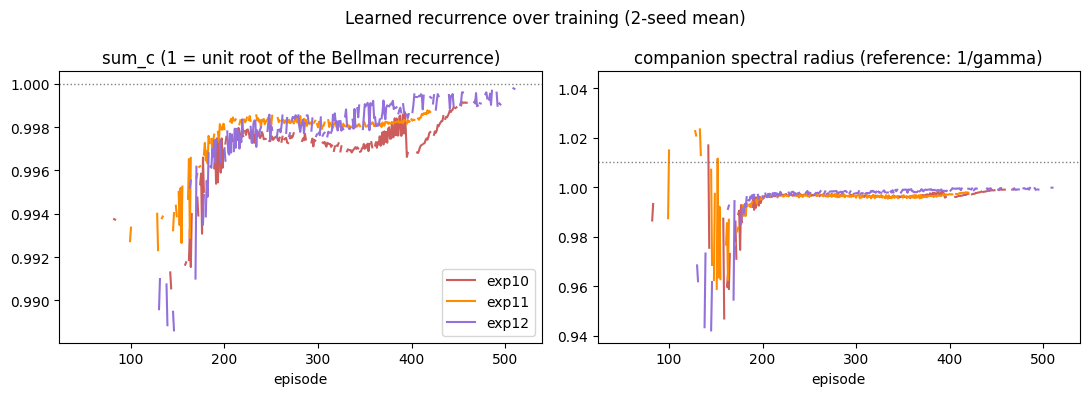

In [9]:
# -- learned recurrence coefficients (one panel per experiment arm) -----------
gamma = cfg_shared["algo"]["gamma"]
c_d_cols = {}   # per-arm coefficient columns, reused by the summary cell
fig, axes = plt.subplots(1, len(ARMS_FHR), figsize=(5 * len(ARMS_FHR), 4),
                         squeeze=False)
for ax, arm in zip(axes[0], ARMS_FHR):
    diags, order = diags_by_arm[arm], agent_by_arm[arm]["fhr_order"]
    c_cols = [f"c_{j}" for j in range(1, order + 1) if f"c_{j}" in diags[0]]
    d_cols = [f"d_{j}" for j in range(1, order + 1) if f"d_{j}" in diags[0]]
    c_d_cols[arm] = c_cols + d_cols
    for col in c_cols + d_cols:
        ax.plot(*diag_seed_mean(diags, col), label=col)
    ax.axhline(1 + 1 / gamma, ls=":", c="gray", lw=1)
    ax.axhline(-1 / gamma, ls=":", c="gray", lw=1)
    ax.set_title(arm_label(arm))
    ax.set_xlabel("episode")
    ax.legend()
fig.suptitle("Learned recurrence coefficients (seed mean; dotted: constant-reward Bellman values)")
fig.tight_layout()
save_and_show(fig, "coefficients")

# -- recurrence health: unit root + companion spectral radius -----------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for arm in ARMS_FHR:
    axes[0].plot(*diag_seed_mean(diags_by_arm[arm], "sum_c"),
                 color=ARM_COLORS[arm], label=arm)
    axes[1].plot(*diag_seed_mean(diags_by_arm[arm], "companion_radius"),
                 color=ARM_COLORS[arm])
axes[0].axhline(1.0, ls=":", c="gray", lw=1)
axes[0].set_title("sum_c (1 = unit root of the Bellman recurrence)")
axes[0].legend()
axes[1].axhline(1 / gamma, ls=":", c="gray", lw=1)
axes[1].set_title("companion spectral radius (reference: 1/gamma)")
for ax in axes:
    ax.set_xlabel("episode")
fig.suptitle(f"Learned recurrence over training ({len(SEEDS)}-seed mean)")
fig.tight_layout()
save_and_show(fig, "recurrence_health")

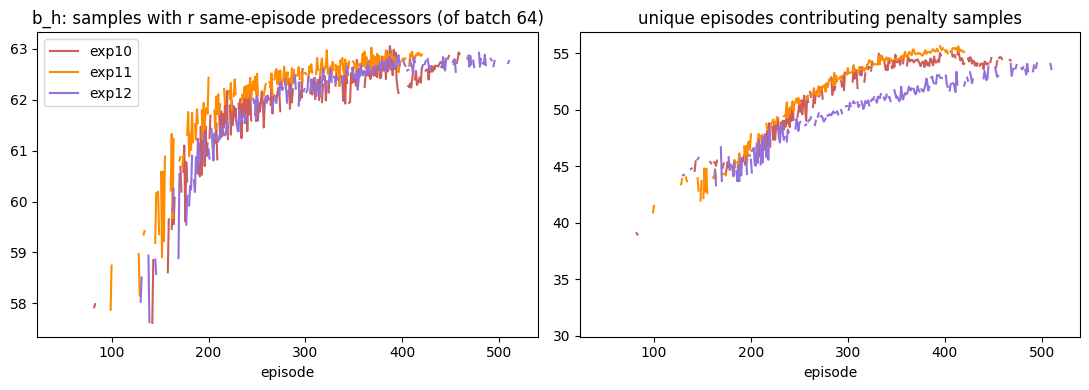

In [10]:
# -- penalty batch composition (seed means) ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for arm in ARMS_FHR:
    axes[0].plot(*diag_seed_mean(diags_by_arm[arm], "b_h"),
                 color=ARM_COLORS[arm], label=arm)
    axes[1].plot(*diag_seed_mean(diags_by_arm[arm], "unique_eps"),
                 color=ARM_COLORS[arm])
axes[0].set_title("b_h: samples with r same-episode predecessors (of batch %d)"
                  % cfg_shared["algo"]["batch_size"])
axes[0].legend()
axes[1].set_title("unique episodes contributing penalty samples")
for ax in axes:
    ax.set_xlabel("episode")
fig.tight_layout()
save_and_show(fig, "penalty_batch")

In [11]:
# -- summary -----------------------------------------------------------------
def solve_episode(rewards, solved, patience=50):
    roll = rolling(rewards, patience)
    idx = np.argmax(roll > solved)
    return int(idx + patience) if roll.max() > solved else None

solved = cfg_shared["training"]["solved_reward"]
for arm, runs in ALL_ARMS:
    bests = [rolling(r["rewards"]).max() for r in runs]
    solves = [solve_episode(r["rewards"], solved) for r in runs]
    # env steps consumed up to the solve episode — the sample-complexity number
    samples = [int(env_steps_axis(r)[s - 1]) if s is not None else None
               for r, s in zip(runs, solves)]
    solved_eps = [s for s in solves if s is not None]
    solved_smp = [s for s in samples if s is not None]
    mean_solve = f"{np.mean(solved_eps):.0f}" if solved_eps else "n/a"
    mean_smp = f"{np.mean(solved_smp):,.0f}" if solved_smp else "n/a"
    print(f"{arm_label(arm)}: mean best rolling-50 {np.mean(bests):.1f} | "
          f"solved {len(solved_eps)}/{len(runs)} seeds | mean solve episode {mean_solve} "
          f"| mean env steps to solve {mean_smp}")
    for r, b, s, smp in zip(runs, bests, solves, samples):
        total = int(env_steps_axis(r)[-1])
        print(f"    seed {r['seed']}: {len(r['rewards'])} episodes / {total:,} env steps, "
              f"best rolling-50 {b:.1f}, solved at episode {s}"
              + (f" ({smp:,} env steps)" if smp is not None else ""))

for arm in ARMS_FHR:
    final = {c: np.mean([d[c][-1] for d in diags_by_arm[arm]])
             for c in c_d_cols[arm] + ["sum_c", "companion_radius"]}
    print(f"{arm} final coefficients (seed mean): "
          + ", ".join(f"{c}={final[c]:.4f}" for c in c_d_cols[arm])
          + f" | sum_c={final['sum_c']:.4f}"
          + f" | companion radius={final['companion_radius']:.4f} (1/gamma={1/gamma:.4f})")
print("nan_skips: " + " | ".join(
    arm + " " + ", ".join(f"{d['nan_skips'][-1]:.0f}" for d in diags)
    for arm, diags in ALL_DIAGS))

baseline (stock SB3, fhr_weight = 0): mean best rolling-50 229.9 | solved 0/2 seeds | mean solve episode n/a | mean env steps to solve n/a
    seed 44: 567 episodes / 50,171 env steps, best rolling-50 195.1, solved at episode None
    seed 66: 552 episodes / 50,162 env steps, best rolling-50 264.6, solved at episode None
exp10 (lambda=0.5, r=2): mean best rolling-50 370.2 | solved 0/2 seeds | mean solve episode n/a | mean env steps to solve n/a
    seed 44: 395 episodes / 49,970 env steps, best rolling-50 387.6, solved at episode None
    seed 66: 469 episodes / 50,147 env steps, best rolling-50 352.8, solved at episode None
exp11 (lambda=1, r=2): mean best rolling-50 304.0 | solved 0/2 seeds | mean solve episode n/a | mean env steps to solve n/a
    seed 44: 393 episodes / 49,907 env steps, best rolling-50 291.0, solved at episode None
    seed 66: 421 episodes / 50,051 env steps, best rolling-50 317.0, solved at episode None
exp12 (lambda=0.1, r=2): mean best rolling-50 221.8 | solve

## Mechanism: low-rank structure over training (seed-averaged)

Every run records the greedy-rollout Hankel sweep (`hankel_sweep.csv`) and the
state-grid Q-matrix rank (`rank_stats.csv`) every `analysis.ep_freq` episodes —
these curves are the mechanism claim: does the FHR penalty pull the
value-sequence Hankel toward the target rank faster than the stock SB3
baseline? Per-episode spectra figures live in each run's `figures/`
(browsable in the result viewer).

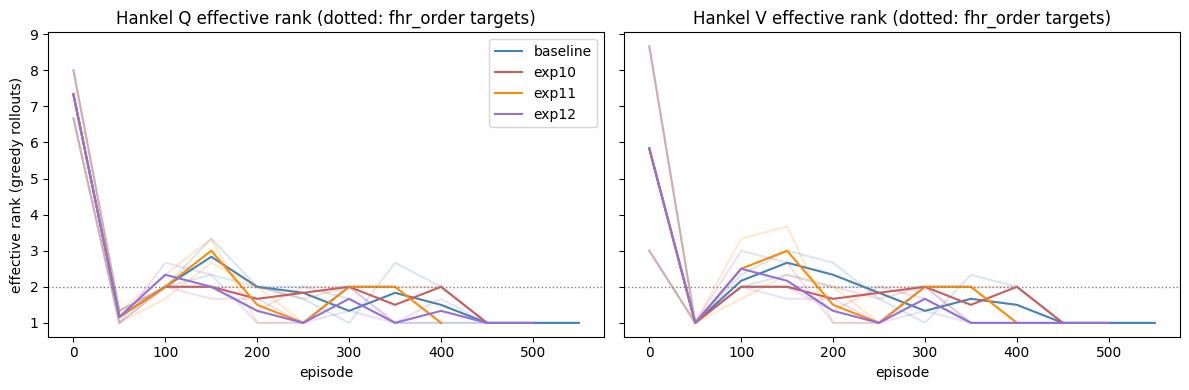

In [12]:
# -- Hankel effective rank over training (thin = seeds, thick = mean) ---------
def rank_rows(run_dir, csv_name, matrix, col="eff_rank"):
    """{episode: mean of `col` over rollouts} for one run."""
    with open(pathlib.Path(run_dir) / csv_name) as f:
        rows = [r for r in csv.DictReader(f) if r["matrix"] == matrix]
    eps = sorted({int(r["episode"]) for r in rows})
    return {e: np.mean([float(r[col]) for r in rows if int(r["episode"]) == e])
            for e in eps}

def arm_rank_stack(runs, csv_name, matrix, col="eff_rank"):
    """(episode axis, (n_seeds, n_ticks) NaN-padded stack) across an arm."""
    per = [rank_rows(r["run_dir"], csv_name, matrix, col) for r in runs]
    all_eps = sorted(set().union(*per))
    stack = np.array([[p.get(e, np.nan) for e in all_eps] for p in per], float)
    return np.array(all_eps), stack

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, matrix in zip(axes, ("Hankel Q", "Hankel V")):
    for arm, runs in ALL_ARMS:
        eps, stack = arm_rank_stack(runs, "hankel_sweep.csv", matrix)
        for row in stack:
            ax.plot(eps, row, color=ARM_COLORS[arm], alpha=0.2)
        ax.plot(eps, np.nanmean(stack, axis=0), color=ARM_COLORS[arm], label=arm)
    for order in sorted({agent_by_arm[a]["fhr_order"] for a in ARMS_FHR}):
        ax.axhline(order, ls=":", c="gray", lw=1)
    ax.set_title(f"{matrix} effective rank (dotted: fhr_order targets)")
    ax.set_xlabel("episode")
axes[0].set_ylabel("effective rank (greedy rollouts)")
axes[0].legend()
fig.tight_layout()
save_and_show(fig, "hankel_rank_evolution")

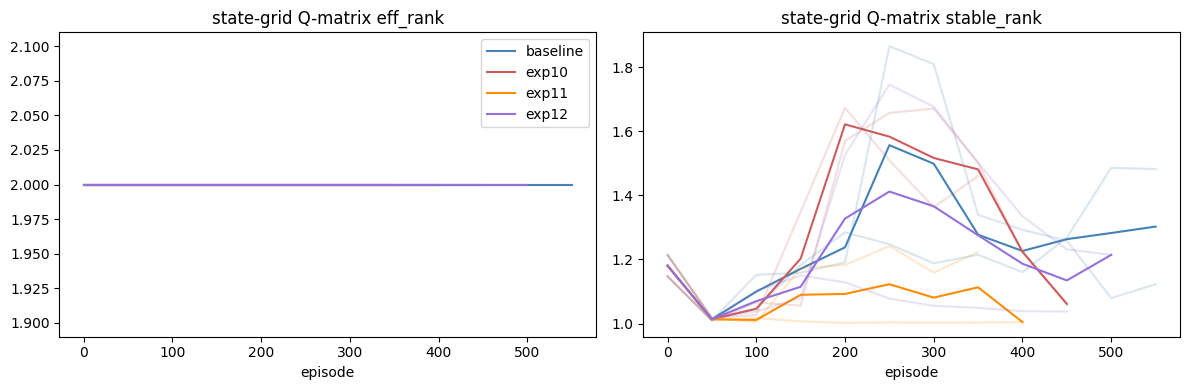

In [13]:
# -- state-grid Q-matrix rank over training ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ("eff_rank", "stable_rank")):
    for arm, runs in ALL_ARMS:
        eps, stack = arm_rank_stack(runs, "rank_stats.csv", "Q-function", col)
        for row in stack:
            ax.plot(eps, row, color=ARM_COLORS[arm], alpha=0.2)
        ax.plot(eps, np.nanmean(stack, axis=0), color=ARM_COLORS[arm], label=arm)
    ax.set_title(f"state-grid Q-matrix {col}")
    ax.set_xlabel("episode")
axes[0].legend()
fig.tight_layout()
save_and_show(fig, "q_matrix_rank")

## Final greedy policies (video)

One greedy episode per (arm, seed), rolled out from `checkpoints/final.pt`
(the SB3 checkpoint zip carries the FHR coefficients itself) and reset with
the run's own seed; saved to `<run_dir>/videos/` and embedded below.

In [14]:
from IPython.display import Video, display
from run_sb3_seeds import record_final_videos

for arm in ["baseline"] + ARMS_FHR:
    for seed, path in record_final_videos(arm):
        print(f"{arm} — seed {seed}: {path.name}")
        display(Video(str(path), embed=True, width=420))

baseline — seed 44: epfinal-episode-0.mp4


baseline — seed 66: epfinal-episode-0.mp4


exp10 — seed 44: epfinal-episode-0.mp4


exp10 — seed 66: epfinal-episode-0.mp4


exp11 — seed 44: epfinal-episode-0.mp4


exp11 — seed 66: epfinal-episode-0.mp4


exp12 — seed 44: epfinal-episode-0.mp4


exp12 — seed 66: epfinal-episode-0.mp4
